# Exam Project

Import and set magics:

In [1]:
# Import all necessary packages
import numpy as np
import pandas as pd
from scipy import optimize
from scipy.stats import norm
import matplotlib.pyplot as plt

# APIs
from dstapi import DstApi

# plotting
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# import py-files
import Problem1, Problem2
from PortfolioModel import PortfolioModelClass

## Problem 1

### Question 1.a

We solve this by...

We find that...

### Question 1.b

We solve this by...

We find that...

### Question 1.c

We solve this by...

We find that...

### Question 1.d

We solve this by...

We find that...

### Question 1.e

We solve this by...

We find that...

## Problem 2

### Question 2.a

We solve this by...

We find that...

### Question 2.b

We solve this by...

We find that...

### Question 2.c

We solve this by...

We find that...

### Question 2.d

We solve this by...

We find that...

### Question 2.e   

We solve this by...

We find that...

## Problem 3

### Question 3.1

#### Question 3.1.1

We draw $\epsilon_t$ for all periods T and simulations N. 

In [2]:
# Question 3.1.1

# A. Run standard PortfolioModelClass and draw returns
model_std = PortfolioModelClass()
R_std = model_std.draw_returns()

# B. Printing first 5 periods for the first 5 simulations
print(R_std[0:5,0:5])

[[0.89706721 1.10308881 0.71945214 1.38979234 1.19441789]
 [1.09514201 0.9271894  0.89122059 1.40335164 1.18387053]
 [1.42687237 0.91045045 1.06339625 1.15384498 1.13273157]
 [1.31482244 0.9591839  0.91731721 1.29407552 1.21416914]
 [1.1903632  1.8844148  1.26865618 0.87075194 1.79088165]]


#### Question 3.1.2

We report the mean and the standard deviation of $\log R_t$ across all draws and compare with the mathematical expectation.

In [3]:
# Question 3.1.2

# A. Calculate the mean of log of return and compare to parameter mu
print(f"The mean log(R) across all draws is: {np.mean(np.log(R_std)):.5f}")
print("The parameter mu is:", model_std.par.mu)
print()

# B. Calculate standard deviation of log of return and compare to parameter sigma
print(f"The standard deviation of log(R) across all draws is: {np.std(np.log(R_std)):.5f}")
print("The parameter sigma is:", model_std.par.sigma)
print()

# C. Calculate the mean of return and compare to mathematical expectation of log-normal distribution
print(f"The mean of R across all draws is: {np.mean(R_std):.5f}")
print("The mathematical expectation of log-normal distribution is:", np.exp(model_std.par.mu +0.5*model_std.par.sigma**2))

The mean log(R) across all draws is: 0.05002
The parameter mu is: 0.05

The standard deviation of log(R) across all draws is: 0.19997
The parameter sigma is: 0.2

The mean of R across all draws is: 1.07253
The mathematical expectation of log-normal distribution is: 1.0725081812542165


Comparing the mean of $R_t$ with the mathematical expectation of the log-normal distribution reveals that these are very much the same. 

#### Question 3.1.3

We plot a figure with two panels containing a histogram and the returns of the risky- and safe assets.

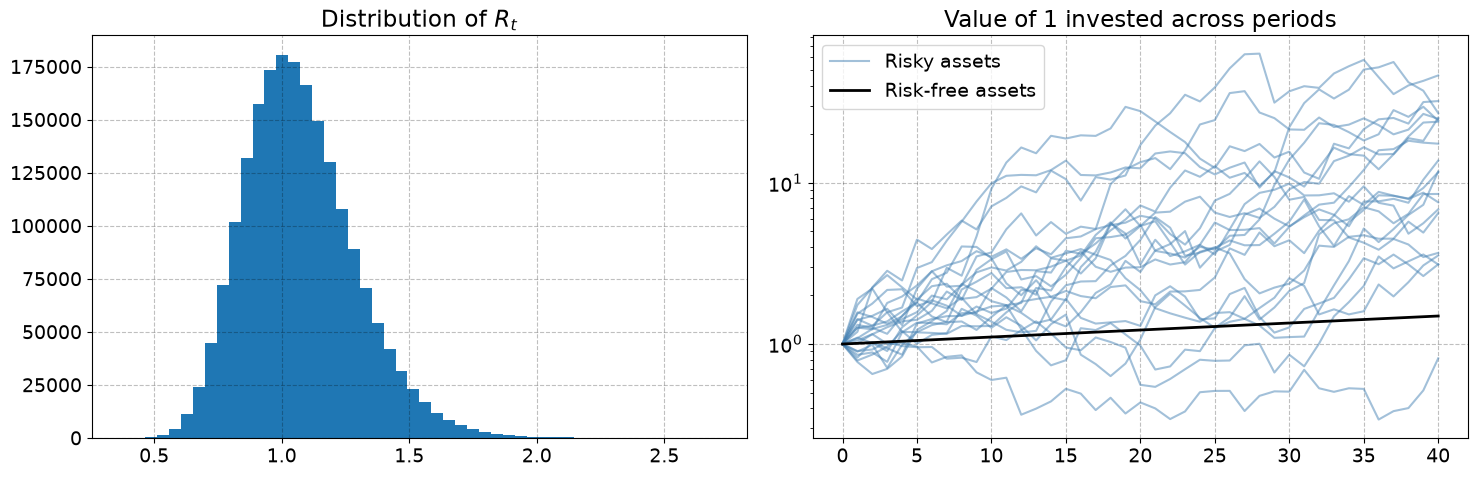

In [4]:
# Question 3.1.3

# A. The period number
t = np.arange(model_std.par.T+1)

# B. The total return of risky assets
total_return_risky = np.cumprod(R_std, axis=1)
total_return_risky = np.hstack([np.ones((model_std.par.N, 1)), total_return_risky])

# C. The total return of risk-free assets
total_return_riskfree = np.exp(model_std.par.r * t)

# D. Two panel plot of histogram of R and total return
fig, ax = plt.subplots(1,2, figsize=(15,5))

# i. Histogram of R
ax[0].set_title("Distribution of $R_t$")
ax[0].hist(R_std.flatten(), bins=50)

# ii. Total return of risky and risk-free assets
ax[1].set_title("Value of 1 invested across periods")
ax[1].plot(t, total_return_risky[1:20, :].T, color="steelblue", alpha=0.5)
ax[1].plot(t, total_return_risky[:1, :].T, color="steelblue", alpha=0.5, label='Risky assets') #single line for legend
ax[1].plot(t, total_return_riskfree, color='black', lw=2, label='Risk-free assets')
ax[1].set_yscale('log')
ax[1].legend()

plt.tight_layout()
plt.show()

### Question 3.2

#### Question 3.2.1

We implement the simulator and store wealth and $\theta$'s for all periods.

In [5]:
# Question 3.2.1

# A. Running standard model
model_std2 = PortfolioModelClass()
R = model_std2.draw_returns() # Saving the drawn returns to be used in other questions
model_std2.simulate(R)

# B. Saving the simulated wealth and portfolio weights
W_std = model_std2.sim.W
theta_std = model_std2.sim.theta


#### Question 3.2.2

The tax on trading is set to 0 and the model is simulated for $\Delta$ equal to 0 and 1 respectively. The returns drawn previously are used in both.

In [6]:
# Question 3.2.2

# A. Simulating the model with no taxes and Delta=0 and Delta=1

# i.
model_notax_deltazero = PortfolioModelClass(tau=0, Delta=0)
model_notax_deltazero.simulate(R) # Simulating the model with the same drawn returns as before
results_notax_deltazero = model_notax_deltazero.summary()

# ii.
model_notax_deltaone = PortfolioModelClass(tau=0, Delta=1)
model_notax_deltaone.simulate(R) # Simulating the model with the same drawn returns as before
results_notax_deltaone = model_notax_deltaone.summary()


# B. Creating a table with the results of the two simulations
rows = {0: results_notax_deltazero, 1: results_notax_deltaone}
table = pd.DataFrame(rows).T
table.index.name = 'Delta'
table.columns = ['Number of trades', 'Avg distance to target', 'Mean terminal wealth', 'Median terminal wealth', '10th percentile of terminal wealth', 'Mean expected utility of terminal wealth']

table.style.format({
    'Number of trades': '{:.0f}',
    'Avg distance to target': '{:.3f}',
    'Mean terminal wealth': '{:.3f}',
    'Median terminal wealth': '{:.3f}',
    '10th percentile of terminal wealth': '{:.3f}',
    'Mean expected utility of terminal wealth': '{:.3f}',
}).format_index('{:.0f}', axis=0)

,Number of trades,Avg distance to target,Mean terminal wealth,Median terminal wealth,10th percentile of terminal wealth,Mean expected utility of terminal wealth
Delta,,,,,,
0,39,0.039,5.044,4.081,1.794,-0.068
1,0,0.191,8.976,4.448,1.485,-0.077


#### Question 3.2.3

We make a figure containing a histogram of terminal wealth for both rules and a plot of the mean of $\theta$ across periods for the two rules.

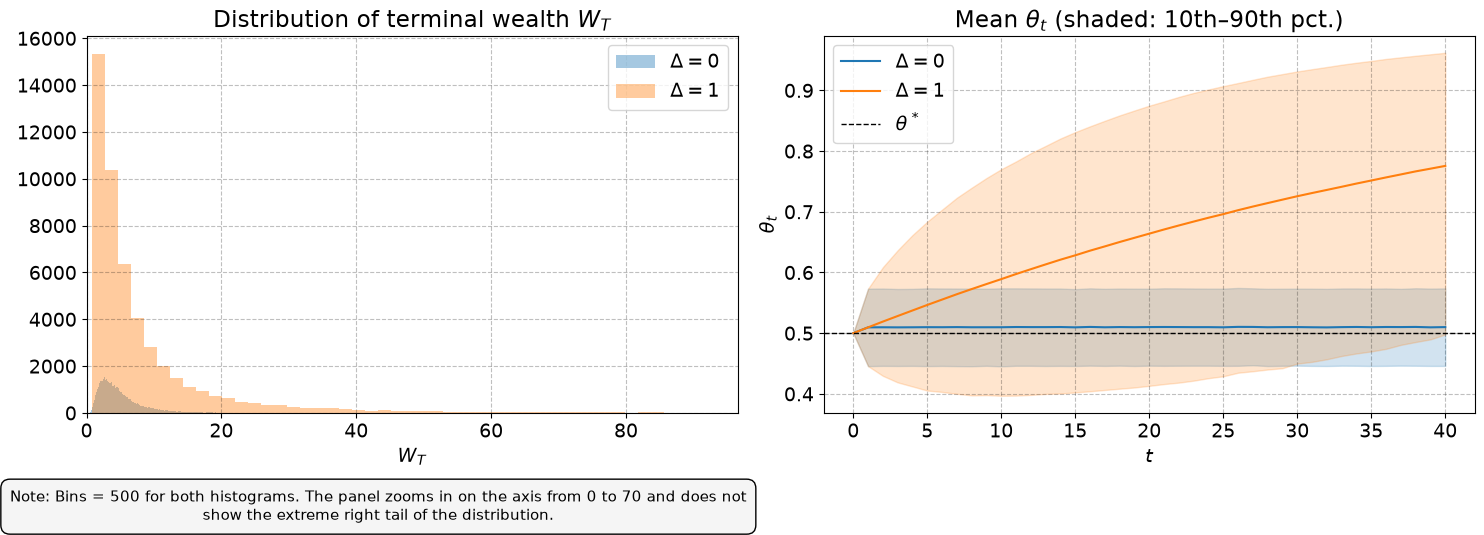

In [7]:
# Question 3.2.3

# A. Figure with two panels
bins = 500
fig, ax = plt.subplots(1, 2, figsize=(15,5))

# B. Histogram of terminal wealth for the two simulations
ax[0].hist(model_notax_deltazero.sim.W[:,-1], bins=bins, color=colors[0], alpha=0.4, label=r'$\Delta = 0$')
ax[0].hist(model_notax_deltaone.sim.W[:,-1], bins=bins, color=colors[1], alpha=0.4, label=r'$\Delta = 1$')
ax[0].set_title('Distribution of terminal wealth $W_T$')
ax[0].set_xlabel('$W_T$')
ax[0].legend()
ax[0].set_xlim(0, np.percentile(model_notax_deltaone.sim.W[:,-1], 99.5))
fig.subplots_adjust(bottom=0.25)

fig.text(
    0.255, -0,
    'Note: Bins = 500 for both histograms. The panel zooms in on the axis from 0 to 70 and does not show the extreme right tail of the distribution.',
    ha='center', va='top', wrap=True, fontsize=11,
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#f5f5f5', edgecolor='black')
)

# C. Theta over time for the two simulations
theta_deltazero = model_notax_deltazero.sim.theta
theta_deltaone = model_notax_deltaone.sim.theta

mean_theta_deltazero = np.mean(theta_deltazero, axis=0)
p10_theta_deltazero = np.percentile(theta_deltazero, 10, axis=0)
p90_theta_deltazero = np.percentile(theta_deltazero, 90, axis=0)

mean_theta_deltaone = np.mean(theta_deltaone, axis=0)
p10_theta_deltaone = np.percentile(theta_deltaone, 10, axis=0)
p90_theta_deltaone = np.percentile(theta_deltaone, 90, axis=0)

ax[1].plot(t, mean_theta_deltazero, color=colors[0], label=r'$\Delta = 0$')
ax[1].fill_between(t, p10_theta_deltazero, p90_theta_deltazero, color=colors[0], alpha=0.2)

ax[1].plot(t, mean_theta_deltaone, color=colors[1], label=r'$\Delta = 1$')
ax[1].fill_between(t, p10_theta_deltaone, p90_theta_deltaone, color=colors[1], alpha=0.2)

ax[1].axhline(model_notax_deltazero.par.theta_star, color='black', linestyle='--', lw=1, label=r'$\theta^*$')
ax[1].set_title(r'Mean $\theta_t$ (shaded: 10th–90th pct.)')
ax[1].set_xlabel('$t$')
ax[1].set_ylabel(r'$\theta_t$')
ax[1].legend()


plt.tight_layout()
plt.show()



#### Question 3.2.4

When the portfolio is never traded ($\Delta=1$), $\theta_t$ drifts steadily upward from the starting value $\theta_0 = 0.5$, reaching a mean of roughly $0.78$ by $t=40$, because the risky asset's higher expected return ($\mu=0.05 > r=0.01$) means its share of wealth compounds faster on average with no rebalancing to pull it back. At the same time, the $10\text{th}$–$90\text{th}$ percentile band widens dramatically over time, from a narrow range around $\theta^*=0.5$ at $t=0$ to spanning roughly $[0.4,,1.0]$ by $t=40$, since without any correction each portfolio's risky share evolves as an unconstrained, path-dependent accumulation of realized returns $R_t = \exp(\mu+\sigma\varepsilon_t)$ rather than a mean-reverting process. This contrasts sharply with $\Delta=0$, whose band (shown in blue) stays narrow and centered on $0.5$ throughout, because constant rebalancing resets $\theta_t$ to $\theta^*$ every single period and prevents any drift or accumulation of dispersion. In short, never trading lets both $\mathbb{E}[\theta_t]$ and its cross-sectional dispersion grow without bound over the horizon, whereas continuous rebalancing keeps both anchored near the target $\theta^*$.

### Question 3.3

#### Question 3.3.1

We simulate the model for the different sizes of $\Delta$ and output the six numbers in a table.

In [8]:
# Question 3.3.1

# A. Running standard model with different delta values
delta_values = [0, 0.025, 0.05, 0.075, 0.1, 0.15, 0.2, 0.3, 1]

results = {}
for delta in delta_values:
    model = PortfolioModelClass(tau=0.01, Delta=delta)
    model.simulate(R) # Using the same drawn returns as in a previous question
    results[delta] = model.summary()

# B. Creating a table with the results of all Delta simulations
table_delta = pd.DataFrame(results).T
table_delta.index.name = 'Delta'
table_delta.columns = ['Mean number of trades', 'Avg distance to target', 'Mean terminal wealth', 'Median terminal wealth', '10th percentile of terminal wealth', 'Mean expected utility of terminal wealth']

table_delta.style.format({
    'Mean number of trades': '{:.2f}',
    'Avg distance to target': '{:.4f}',
    'Mean terminal wealth': '{:.4f}',
    'Median terminal wealth': '{:.4f}',
    '10th percentile of terminal wealth': '{:.4f}',
    'Mean expected utility of terminal wealth': '{:.4f}',
}).format_index('{:.3f}', axis=0)

,Mean number of trades,Avg distance to target,Mean terminal wealth,Median terminal wealth,10th percentile of terminal wealth,Mean expected utility of terminal wealth
Delta,,,,,,
0.000,39.00,0.0394,4.9624,4.0184,1.7683,-0.0699
0.025,24.52,0.0400,4.9746,4.0184,1.7692,-0.0697
0.050,14.33,0.0429,5.0155,4.0358,1.7674,-0.0695
0.075,8.79,0.0480,5.0739,4.0476,1.7655,-0.0693
0.100,5.86,0.0541,5.1459,4.0606,1.7594,-0.0695
0.150,3.15,0.0680,5.3285,4.1042,1.7353,-0.0700
0.200,1.95,0.0835,5.5596,4.1863,1.6792,-0.0709
0.300,0.91,0.1180,6.1957,4.3414,1.5361,-0.0734
1.000,0.00,0.1911,8.9756,4.4478,1.4855,-0.0767


#### Question 3.3.2

We make a figure containing a plot of the number of trades and the average distance to the target across $\Delta$ values in one panel and the expected utility across $\Delta$ values in a second panel.

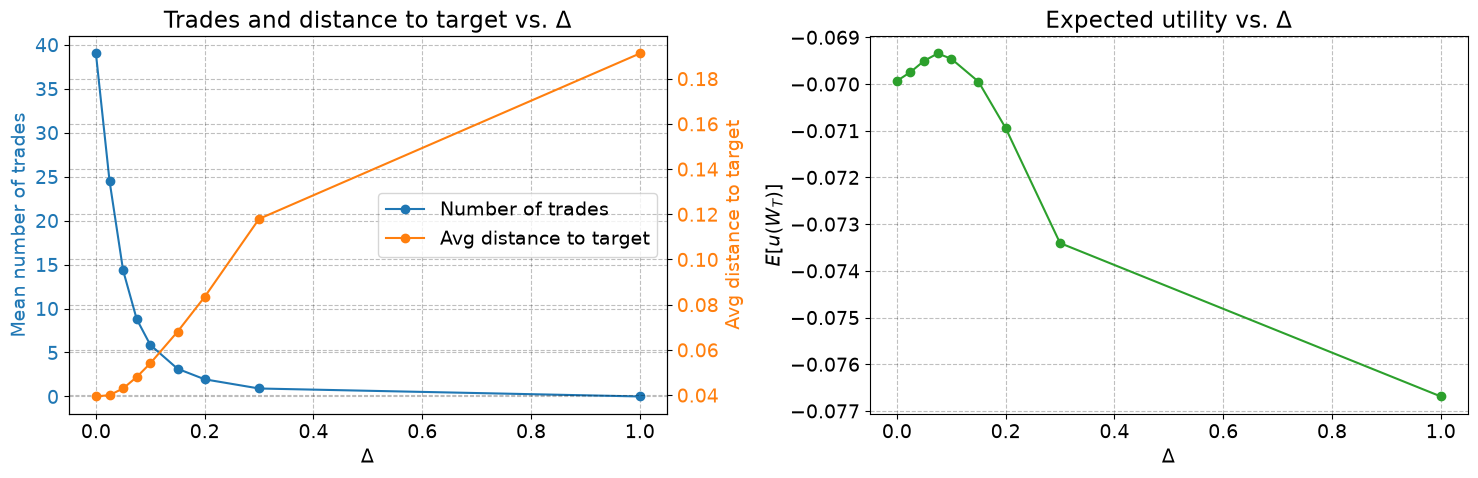

In [9]:
# Question 3.3.2

# A. Figure with two panels
deltas_arr = table_delta.index.values
fig, ax = plt.subplots(1, 2, figsize=(15,5))

# Left panel: number of trades and distance to target
ax0b = ax[0].twinx()
l1, = ax[0].plot(deltas_arr, table_delta['Mean number of trades'], color=colors[0], marker='o', label='Number of trades')
l2, = ax0b.plot(deltas_arr, table_delta['Avg distance to target'], color=colors[1], marker='o', label='Avg distance to target')
ax[0].set_xlabel(r'$\Delta$')
ax[0].set_ylabel('Mean number of trades', color=colors[0])
ax0b.set_ylabel('Avg distance to target', color=colors[1])
ax[0].tick_params(axis='y', labelcolor=colors[0])
ax0b.tick_params(axis='y', labelcolor=colors[1])
ax[0].set_title(r'Trades and distance to target vs. $\Delta$')
lines = [l1, l2]
ax[0].legend(lines, [l.get_label() for l in lines], loc='center right')

# Right panel: expected utility of terminal wealth
ax[1].plot(deltas_arr, table_delta['Mean expected utility of terminal wealth'], color=colors[2], marker='o')
ax[1].set_xlabel(r'$\Delta$')
ax[1].set_ylabel(r'$E[u(W_T)]$')
ax[1].set_title(r'Expected utility vs. $\Delta$')


plt.tight_layout()
plt.show()




#### Question 3.3.3

Finding the $\Delta$ that maximizes expected utility and comparing that to the two rules.

In [10]:
# Question 3.3.3

# Locating the best Delta and comparing expected utility to Delta=0 and Delta=1
best_delta = table_delta['Mean expected utility of terminal wealth'].idxmax()
ax[1].axvline(best_delta, color='black', linestyle='--', lw=1, label=fr'best $\Delta = {best_delta:.3f}$')
ax[1].legend()

print(f"Best Delta: {best_delta:.3f}")
print(f"EU at best Delta: {table_delta.loc[best_delta, 'Mean expected utility of terminal wealth']:.4f}")
print(f"EU at Delta=0:    {table_delta.loc[0.0, 'Mean expected utility of terminal wealth']:.4f}")
print(f"EU at Delta=1:    {table_delta.loc[1.0, 'Mean expected utility of terminal wealth']:.4f}")

Best Delta: 0.075
EU at best Delta: -0.0693
EU at Delta=0:    -0.0699
EU at Delta=1:    -0.0767


The $\Delta$ yielding the highest expected utility is $\Delta=0.075$. This yields $E[u(W_T)] = -0.0693$, an improvement of $0.0006$ over $\Delta=0$ ($E[u(W_T)]=-0.0699$) and an improvement of $0.0074$ over $\Delta=1$ ($E[u(W_T)]=-0.0767$).

#### Question 3.3.4

 As $\Delta$ grows, the number of trades falls sharply and monotonically from ~39 ($\Delta$=0, trade almost every period) toward 0 ($\Delta$=1, never trade), while the average distance to target rises monotonically in the opposite direction, from near 0 to ~0.19 — fewer corrections mechanically mean the portfolio is allowed to drift further from the 50% target.

Expected utility is hump-shaped rather than monotonic: it rises slightly from $\Delta$=0, peaks around $\Delta$≈0.075–0.10, then declines steadily, ending at its lowest point at $\Delta$=1 — so a small no-trade band beats both constant rebalancing and never trading.

This reflects the same trade-off across the six summary numbers: as $\Delta$ grows, mean terminal wealth tends to rise (more risk exposure from drift) but the 10th percentile falls (fatter downside tail), so the risk-averse investor (γ=3) trades off saved transaction costs against growing dispersion, and the two effects roughly balance near the small-to-moderate $\Delta$ that maximizes E[u(W_T)]. Therefore, the same rule of $\Delta$ would not have been picked, had the goal been to maximize the mean terminal wealth.